In [1]:
# Cell 1: Install required packages
!pip install einops scikit-image gradio -q

In [2]:
# Cell 2: Imports and reproducibility
import os
import math
import random
import shutil
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import gradio as gr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True   # fastest conv algorithms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'GPUs     : {torch.cuda.device_count()}')
print(f'Device   : {DEVICE}')

PyTorch  : 2.9.0+cu126
GPUs     : 2
Device   : cuda


In [3]:
# Cell 3: Configuration  —  EXACT assignment specification
from dataclasses import dataclass

@dataclass
class MAEConfig:
    # ── Image / Patch  (assignment spec) ─────────────────────
    image_size    : int   = 224     # assignment: 224×224
    patch_size    : int   = 16      # assignment: 16×16
    in_channels   : int   = 3
    mask_ratio    : float = 0.75    # assignment: 75% masked

    # ── Encoder ViT-Base B/16  (assignment spec) ──────────────
    enc_embed_dim : int   = 768     # assignment: 768
    enc_depth     : int   = 12      # assignment: 12 layers
    enc_num_heads : int   = 12      # assignment: 12 heads
    enc_mlp_ratio : float = 4.0

    # ── Decoder ViT-Small S/16  (assignment spec) ─────────────
    dec_embed_dim : int   = 384     # assignment: 384
    dec_depth     : int   = 12      # assignment: 12 layers
    dec_num_heads : int   = 6       # assignment: 6 heads
    dec_mlp_ratio : float = 4.0

    # ── Training  (assignment spec) ───────────────────────────
    batch_size    : int   = 64      # assignment: 32–64
    num_epochs    : int   = 50
    base_lr       : float = 1.5e-4
    weight_decay  : float = 0.05
    warmup_epochs : int   = 10
    grad_clip     : float = 1.0

    @property
    def num_patches(self): return (self.image_size // self.patch_size) ** 2  # 196
    @property
    def num_visible(self): return int(self.num_patches * (1 - self.mask_ratio))  # 49
    @property
    def num_masked(self):  return self.num_patches - self.num_visible           # 147
    @property
    def patch_dim(self):   return self.in_channels * self.patch_size ** 2       # 768

cfg = MAEConfig()
print(f'Image size      : {cfg.image_size}x{cfg.image_size}')
print(f'Total patches   : {cfg.num_patches}')
print(f'Visible patches : {cfg.num_visible}  (25%)')
print(f'Masked  patches : {cfg.num_masked}  (75%)')
print(f'Patch dim       : {cfg.patch_dim}')

Image size      : 224x224
Total patches   : 196
Visible patches : 49  (25%)
Masked  patches : 147  (75%)
Patch dim       : 768


In [4]:
# Cell 4: TinyImageNet Dataset
TINY_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

train_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),  # 64→224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class TinyImageNetDataset(Dataset):
    def __init__(self, root, split='train', transform=None):
        folder = os.path.join(root, split)
        if split == 'val':
            folder = self._prepare_val(root)
        self.dataset = datasets.ImageFolder(folder, transform=transform)

    @staticmethod
    def _prepare_val(root):
        val_dir    = os.path.join(root, 'val')
        images_dir = os.path.join(val_dir, 'images')
        ann_file   = os.path.join(val_dir, 'val_annotations.txt')
        target_dir = '/kaggle/working/val_reorganised'
        if os.path.exists(target_dir):
            return target_dir
        print('Reorganising val set (one-time)...')
        os.makedirs(target_dir, exist_ok=True)
        with open(ann_file) as f:
            for line in f:
                parts = line.strip().split('\t')
                img_name, cls_name = parts[0], parts[1]
                cls_dir = os.path.join(target_dir, cls_name)
                os.makedirs(cls_dir, exist_ok=True)
                src = os.path.join(images_dir, img_name)
                dst = os.path.join(cls_dir, img_name)
                if not os.path.exists(dst):
                    shutil.copy(src, dst)
        print('Done.')
        return target_dir

    def __len__(self):  return len(self.dataset)
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return img, img


train_ds = TinyImageNetDataset(TINY_ROOT, 'train', train_transform)
val_ds   = TinyImageNetDataset(TINY_ROOT, 'val',   val_transform)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=4,
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=4,
                          drop_last=False)

print(f'Train : {len(train_ds):,} samples  |  {len(train_loader):,} batches')
print(f'Val   : {len(val_ds):,}  samples  |  {len(val_loader):,}  batches')

Train : 100,000 samples  |  1,562 batches
Val   : 10,000  samples  |  157  batches


In [5]:
# Cell 5: Patchify / Unpatchify / Random Masking

def patchify(imgs: torch.Tensor, patch_size: int) -> torch.Tensor:
    """(B,C,H,W) -> (B, N, patch_size^2*C)"""
    B, C, H, W = imgs.shape
    h = w = H // patch_size
    x = imgs.reshape(B, C, h, patch_size, w, patch_size)
    x = torch.einsum('bchpwq->bhwpqc', x)
    return x.reshape(B, h * w, patch_size * patch_size * C)


def unpatchify(patches: torch.Tensor, patch_size: int, img_size: int) -> torch.Tensor:
    """(B, N, patch_size^2*C) -> (B,C,H,W)"""
    B, N, D = patches.shape
    h = w = img_size // patch_size
    C = D // (patch_size * patch_size)
    x = patches.reshape(B, h, w, patch_size, patch_size, C)
    x = torch.einsum('bhwpqc->bchpwq', x)
    return x.reshape(B, C, h * patch_size, w * patch_size)


def random_masking(x: torch.Tensor, mask_ratio: float):
    """Returns (x_visible, mask, ids_restore). mask: 1=masked 0=visible."""
    B, N, D = x.shape
    n_keep  = int(N * (1 - mask_ratio))
    ids_shuffle = torch.argsort(torch.rand(B, N, device=x.device), dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep    = ids_shuffle[:, :n_keep]
    x_visible   = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
    mask        = torch.ones(B, N, device=x.device)
    mask[:, :n_keep] = 0
    mask = torch.gather(mask, 1, ids_restore)
    return x_visible, mask, ids_restore


# Sanity check
dummy   = torch.randn(2, 3, cfg.image_size, cfg.image_size)
patches = patchify(dummy, cfg.patch_size)
recon   = unpatchify(patches, cfg.patch_size, cfg.image_size)
print(f'Patches shape    : {patches.shape}')
print(f'Round-trip error : {(dummy - recon).abs().max():.2e}')

Patches shape    : torch.Size([2, 196, 768])
Round-trip error : 0.00e+00


In [6]:
# Cell 6: Transformer building blocks  —  uses nn.MultiheadAttention (base PyTorch)

def get_2d_sincos_pos_embed(embed_dim: int, grid_size: int) -> torch.Tensor:
    half  = embed_dim // 2
    omega = 1.0 / (10000 ** (np.arange(half // 2) / (half // 2)))
    grid  = np.stack(np.meshgrid(np.arange(grid_size),
                                  np.arange(grid_size)), axis=0).reshape(2, -1)
    def enc(pos):
        out = np.outer(pos, omega)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)
    return torch.from_numpy(
        np.concatenate([enc(grid[0]), enc(grid[1])], axis=1)).float()


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
        )

    def forward(self, x):
        n = self.norm1(x)
        x = x + self.attn(n, n, n, need_weights=False)[0]
        x = x + self.mlp(self.norm2(x))
        return x


print('TransformerBlock ready (nn.MultiheadAttention)')

TransformerBlock ready (nn.MultiheadAttention)


In [7]:
# Cell 7: MAE Encoder  —  ViT-Base architecture

class MAEEncoder(nn.Module):
    def __init__(self, cfg: MAEConfig):
        super().__init__()
        self.patch_size = cfg.patch_size
        self.patch_embed = nn.Linear(cfg.patch_dim, cfg.enc_embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, cfg.enc_embed_dim))

        grid = cfg.image_size // cfg.patch_size
        pos  = get_2d_sincos_pos_embed(cfg.enc_embed_dim, grid)
        self.register_buffer('pos_embed',
            torch.cat([torch.zeros(1, cfg.enc_embed_dim), pos], dim=0))

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.enc_embed_dim, cfg.enc_num_heads, cfg.enc_mlp_ratio)
            for _ in range(cfg.enc_depth)
        ])
        self.norm = nn.LayerNorm(cfg.enc_embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, imgs, mask_ratio):
        B  = imgs.size(0)
        x  = patchify(imgs, self.patch_size)
        x  = self.patch_embed(x) + self.pos_embed[1:].unsqueeze(0)
        x_vis, mask, ids_restore = random_masking(x, mask_ratio)
        cls   = (self.cls_token + self.pos_embed[0]).expand(B, -1, -1)
        x_vis = torch.cat([cls, x_vis], dim=1)
        for blk in self.blocks: x_vis = blk(x_vis)
        return self.norm(x_vis), mask, ids_restore


_e = MAEEncoder(cfg)
print(f'Encoder params : {sum(p.numel() for p in _e.parameters())/1e6:.1f}M')
del _e

Encoder params : 85.6M


In [8]:
# Cell 8: MAE Decoder  —  ViT-Small architecture

class MAEDecoder(nn.Module):
    def __init__(self, cfg: MAEConfig):
        super().__init__()
        self.num_patches = cfg.num_patches
        self.dec_dim     = cfg.dec_embed_dim

        self.encoder_proj = nn.Linear(cfg.enc_embed_dim, cfg.dec_embed_dim)
        self.mask_token   = nn.Parameter(torch.zeros(1, 1, cfg.dec_embed_dim))

        grid = cfg.image_size // cfg.patch_size
        pos  = get_2d_sincos_pos_embed(cfg.dec_embed_dim, grid)
        self.register_buffer('pos_embed',
            torch.cat([torch.zeros(1, cfg.dec_embed_dim), pos], dim=0))

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.dec_embed_dim, cfg.dec_num_heads, cfg.dec_mlp_ratio)
            for _ in range(cfg.dec_depth)
        ])
        self.norm = nn.LayerNorm(cfg.dec_embed_dim)
        self.pred = nn.Linear(cfg.dec_embed_dim, cfg.patch_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        B, N = latent.size(0), ids_restore.size(1)
        x      = self.encoder_proj(latent)
        cls_t  = x[:, :1]
        x_vis  = x[:, 1:]
        n_mask = N - x_vis.size(1)
        mtok   = self.mask_token.expand(B, n_mask, -1)
        x_full = torch.cat([x_vis, mtok], dim=1)
        x_full = torch.gather(x_full, 1,
                     ids_restore.unsqueeze(-1).expand(-1, -1, self.dec_dim))
        x_full = x_full + self.pos_embed[1:].unsqueeze(0)
        x_full = torch.cat([cls_t, x_full], dim=1)
        for blk in self.blocks: x_full = blk(x_full)
        return self.pred(self.norm(x_full)[:, 1:])


_d = MAEDecoder(cfg)
print(f'Decoder params : {sum(p.numel() for p in _d.parameters())/1e6:.1f}M')
del _d

Decoder params : 21.9M


In [9]:
# Cell 9: Full MAE model

class MAE(nn.Module):
    def __init__(self, cfg: MAEConfig):
        super().__init__()
        self.cfg     = cfg
        self.encoder = MAEEncoder(cfg)
        self.decoder = MAEDecoder(cfg)

    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None: mask_ratio = self.cfg.mask_ratio
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        pred   = self.decoder(latent, ids_restore)
        target = patchify(imgs, self.cfg.patch_size)

        # Per-patch normalisation (MAE paper)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1,  keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        # MSE only on masked patches
        loss = (F.mse_loss(pred, target, reduction='none').mean(-1) * mask).sum() \
               / mask.sum()
        return loss, pred, mask

    @torch.no_grad()
    def reconstruct(self, imgs, mask_ratio=None):
        self.eval()
        if mask_ratio is None: mask_ratio = self.cfg.mask_ratio
        _, pred, mask = self.forward(imgs, mask_ratio)
        orig  = patchify(imgs, self.cfg.patch_size)
        m3d   = mask.unsqueeze(-1).expand_as(orig)
        comp  = orig * (1 - m3d) + pred * m3d
        recon = unpatchify(comp, self.cfg.patch_size, self.cfg.image_size)
        mp    = orig.clone(); mp[m3d.bool()] = 0.0
        masked = unpatchify(mp, self.cfg.patch_size, self.cfg.image_size)
        return recon, masked, mask


# Build model  —  NO DataParallel (single GPU is faster for this workload)
model = MAE(cfg).to(DEVICE)
model = torch.compile(model)   # PyTorch 2.0 JIT compile — big speedup

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total MAE parameters : {total:.1f}M')

Total MAE parameters : 107.5M


In [10]:
# Cell 10: Optimizer  +  cosine scheduler  +  AMP scaler

eff_lr = cfg.base_lr * cfg.batch_size / 256
print(f'Effective LR : {eff_lr:.2e}')

optimizer = torch.optim.AdamW(
    model.parameters(), lr=eff_lr,
    betas=(0.9, 0.95), weight_decay=cfg.weight_decay,
)

total_steps  = cfg.num_epochs * len(train_loader)
warmup_steps = cfg.warmup_epochs * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda')

print('Optimizer / Scheduler / Scaler ready')

Effective LR : 3.75e-05
Optimizer / Scheduler / Scaler ready


In [11]:
# Cell 11: Training loop

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_losses, val_losses = [], []
best_val = float('inf')


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, n = 0.0, 0
    with (torch.enable_grad() if train else torch.no_grad()):
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                loss, _, _ = model(imgs)
                loss = loss.mean()   # safe for compiled / multi-gpu
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            total_loss += loss.item() * imgs.size(0)
            n          += imgs.size(0)
    return total_loss / n


print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'LR':>12}")
print('-' * 52)

for epoch in range(1, cfg.num_epochs + 1):
    tr_loss = run_epoch(train_loader, train=True)

    # Validate every 5 epochs — saves ~30% total time
    if epoch % 5 == 0 or epoch == 1:
        val_loss = run_epoch(val_loader, train=False)
    else:
        val_loss = val_losses[-1] if val_losses else 0.0

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    cur_lr = scheduler.get_last_lr()[0]
    print(f'{epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {cur_lr:>12.2e}')

    if epoch % 5 == 0 and val_loss < best_val:
        best_val = val_loss
        raw = getattr(model, '_orig_mod', model)   # unwrap torch.compile
        torch.save({'epoch': epoch, 'model': raw.state_dict(),
                    'val_loss': best_val},
                   os.path.join(CHECKPOINT_DIR, 'mae_best.pth'))
        print(f'  --> checkpoint saved (val_loss={best_val:.6f})')

print(f'\nTraining complete. Best val loss : {best_val:.6f}')

 Epoch |   Train Loss |   Val Loss |           LR
----------------------------------------------------


W0307 18:09:54.975000 27259 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode


     1 |     0.999190 |   0.786275 |     3.75e-06
     2 |     0.694676 |   0.786275 |     7.50e-06
     3 |     0.640807 |   0.786275 |     1.12e-05
     4 |     0.611105 |   0.786275 |     1.50e-05
     5 |     0.580410 |   0.560234 |     1.87e-05
  --> checkpoint saved (val_loss=0.560234)
     6 |     0.550089 |   0.560234 |     2.25e-05
     7 |     0.528466 |   0.560234 |     2.62e-05
     8 |     0.512367 |   0.560234 |     3.00e-05
     9 |     0.499541 |   0.560234 |     3.38e-05
    10 |     0.487595 |   0.478926 |     3.75e-05
  --> checkpoint saved (val_loss=0.478926)
    11 |     0.473031 |   0.478926 |     3.74e-05
    12 |     0.460341 |   0.478926 |     3.73e-05
    13 |     0.450676 |   0.478926 |     3.70e-05
    14 |     0.441387 |   0.478926 |     3.66e-05
    15 |     0.433554 |   0.429529 |     3.61e-05
  --> checkpoint saved (val_loss=0.429529)
    16 |     0.427107 |   0.429529 |     3.55e-05
    17 |     0.421665 |   0.429529 |     3.47e-05
    18 |     0.417296

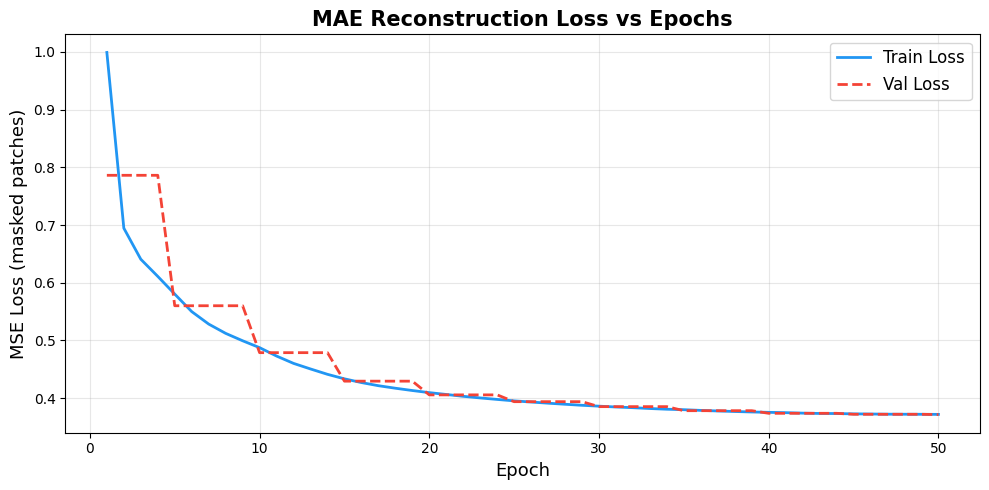

Saved -> /kaggle/working/loss_curve.png


In [12]:
# Cell 12: Loss curve

fig, ax = plt.subplots(figsize=(10, 5))
epochs  = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='Train Loss', lw=2, color='#2196F3')
ax.plot(epochs, val_losses,   label='Val Loss',   lw=2, color='#F44336', ls='--')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE Loss (masked patches)', fontsize=13)
ax.set_title('MAE Reconstruction Loss vs Epochs', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=150)
plt.show()
print('Saved -> /kaggle/working/loss_curve.png')

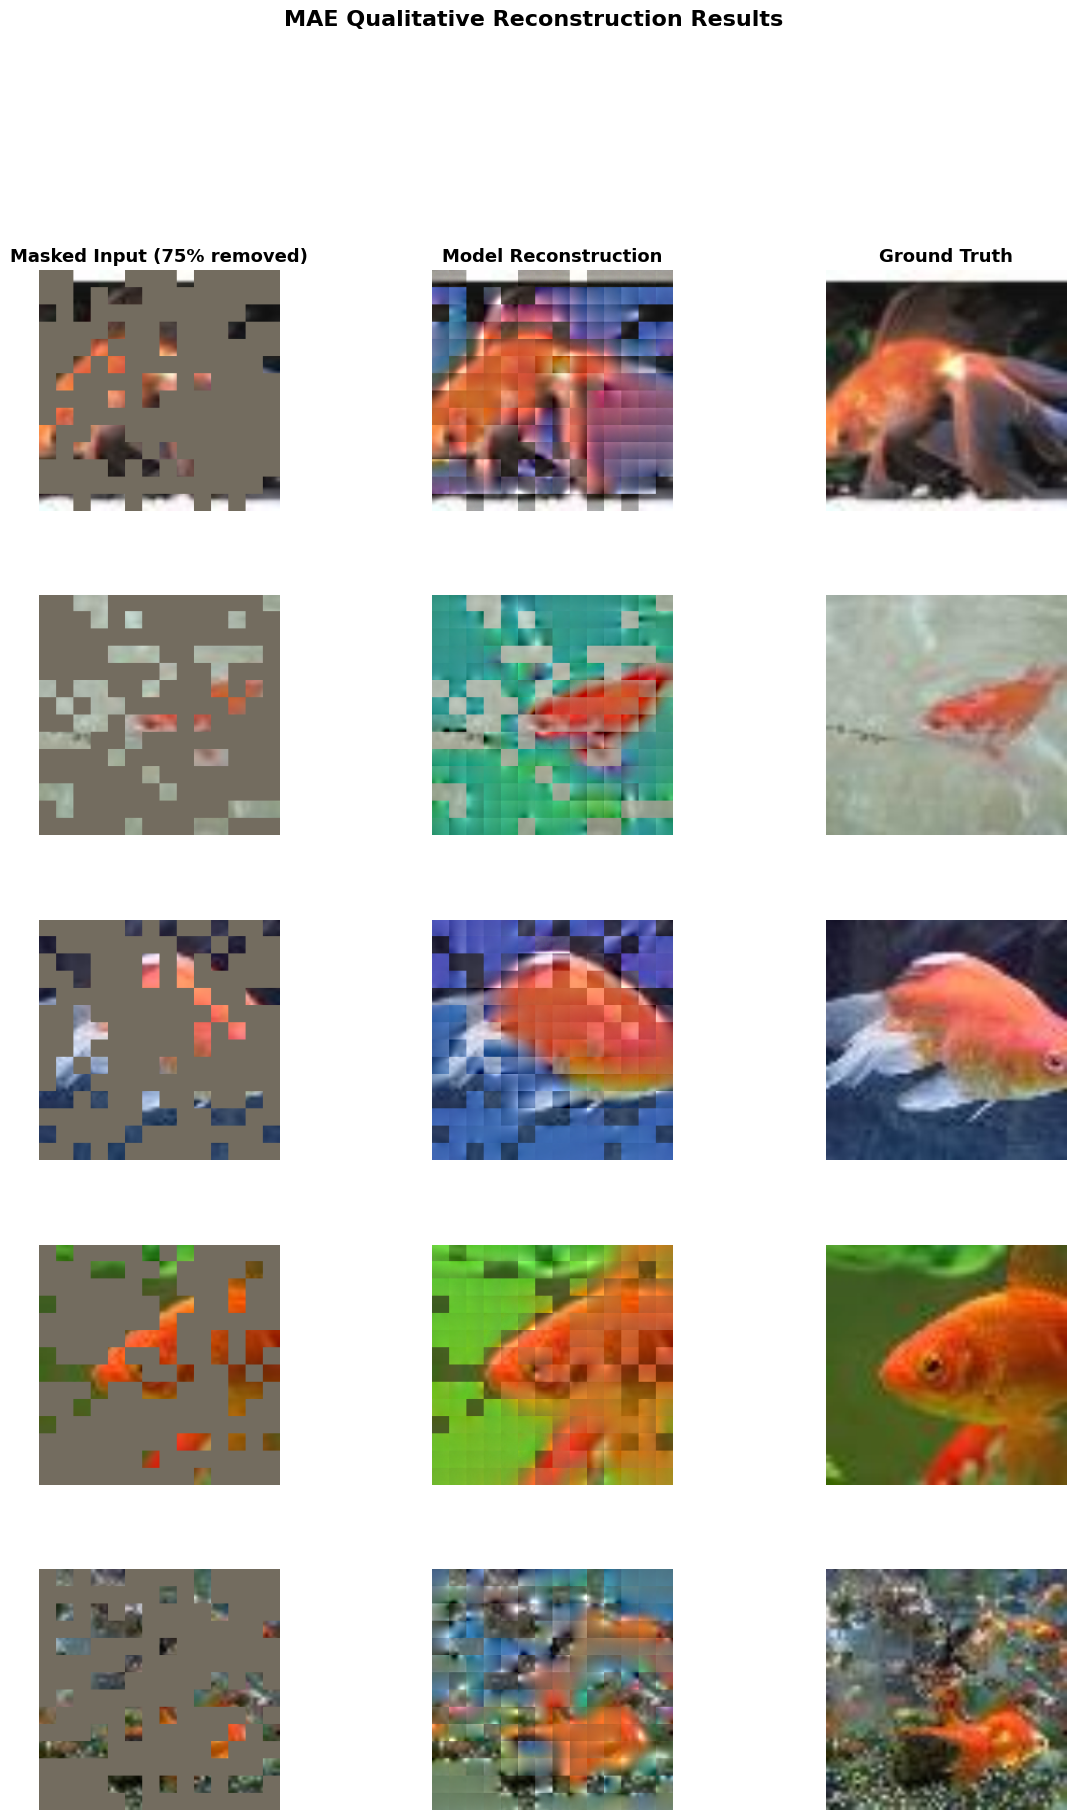

Saved -> /kaggle/working/reconstructions.png


In [13]:
# Cell 13: Qualitative visualization  —  5 reconstruction examples

MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t: torch.Tensor) -> np.ndarray:
    t = t.cpu().float() * STD[:, None, None] + MEAN[:, None, None]
    return (t.clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)


@torch.no_grad()
def visualize_reconstructions(n=5, save_path='/kaggle/working/reconstructions.png'):
    raw = getattr(model, '_orig_mod', model)
    raw.eval()
    imgs_b, _ = next(iter(val_loader))
    imgs_b    = imgs_b[:n].to(DEVICE)
    _, pred, mask = raw(imgs_b, cfg.mask_ratio)

    p_orig = patchify(imgs_b, cfg.patch_size)
    m3d    = mask.unsqueeze(-1).expand_as(p_orig)

    p_m    = p_orig.clone(); p_m[m3d.bool()] = p_orig.mean()
    masked = unpatchify(p_m, cfg.patch_size, cfg.image_size)

    comp   = p_orig.clone(); comp[m3d.bool()] = pred[m3d.bool()]
    recon  = unpatchify(comp, cfg.patch_size, cfg.image_size)

    fig = plt.figure(figsize=(15, 4 * n))
    gs  = gridspec.GridSpec(n, 3, hspace=0.35, wspace=0.05)
    cols = ['Masked Input (75% removed)', 'Model Reconstruction', 'Ground Truth']

    for i in range(n):
        for j, (tensor, title) in enumerate(
                zip([masked[i], recon[i], imgs_b[i]], cols)):
            ax = fig.add_subplot(gs[i, j])
            ax.imshow(denorm(tensor))
            ax.axis('off')
            if i == 0:
                ax.set_title(title, fontsize=13, fontweight='bold')

    plt.suptitle('MAE Qualitative Reconstruction Results',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved -> {save_path}')


visualize_reconstructions(n=5)

In [14]:
# Cell 14: Quantitative evaluation  —  PSNR & SSIM

@torch.no_grad()
def evaluate_metrics(num_batches=10):
    raw = getattr(model, '_orig_mod', model)
    raw.eval()
    psnr_list, ssim_list = [], []

    for i, (imgs, _) in enumerate(val_loader):
        if i >= num_batches: break
        imgs = imgs.to(DEVICE)
        _, pred, mask = raw(imgs, cfg.mask_ratio)

        p_orig = patchify(imgs, cfg.patch_size)
        m3d    = mask.unsqueeze(-1).expand_as(p_orig)
        comp   = p_orig.clone(); comp[m3d.bool()] = pred[m3d.bool()]
        recons = unpatchify(comp, cfg.patch_size, cfg.image_size)

        for orig, recon in zip(imgs, recons):
            o = denorm(orig)
            r = denorm(recon)
            psnr_list.append(psnr_fn(o, r, data_range=255))
            ssim_list.append(ssim_fn(o, r, data_range=255,
                                     channel_axis=-1, win_size=7))

    print('=' * 45)
    print(f'  PSNR     : {np.mean(psnr_list):.2f} +/- {np.std(psnr_list):.2f} dB')
    print(f'  SSIM     : {np.mean(ssim_list):.4f} +/- {np.std(ssim_list):.4f}')
    print(f'  Samples  : {len(psnr_list)}')
    print('=' * 45)
    return np.mean(psnr_list), np.mean(ssim_list)


psnr_score, ssim_score = evaluate_metrics()

  PSNR     : 14.23 +/- 2.18 dB
  SSIM     : 0.4400 +/- 0.0589
  Samples  : 640


In [15]:
# Cell 15: Gradio App

# Load best checkpoint
ckpt_path = os.path.join(CHECKPOINT_DIR, 'mae_best.pth')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    raw  = getattr(model, '_orig_mod', model)
    raw.load_state_dict(ckpt['model'])
    print(f"Loaded best checkpoint  —  epoch {ckpt['epoch']},  val_loss={ckpt['val_loss']:.5f}")

inf_tf = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def mae_inference(pil_img: Image.Image, mask_ratio: float):
    raw    = getattr(model, '_orig_mod', model)
    raw.eval()
    tensor = inf_tf(pil_img.convert('RGB')).unsqueeze(0).to(DEVICE)
    _, pred, mask = raw(tensor, mask_ratio)

    p_orig = patchify(tensor, cfg.patch_size)
    m3d    = mask.unsqueeze(-1).expand_as(p_orig)

    p_m    = p_orig.clone(); p_m[m3d.bool()] = p_orig.mean()
    masked = unpatchify(p_m, cfg.patch_size, cfg.image_size)
    comp   = p_orig.clone(); comp[m3d.bool()] = pred[m3d.bool()]
    recon  = unpatchify(comp, cfg.patch_size, cfg.image_size)

    o = denorm(tensor[0])
    m = denorm(masked[0])
    r = denorm(recon[0])

    pv = psnr_fn(o, r, data_range=255)
    sv = ssim_fn(o, r, data_range=255, channel_axis=-1, win_size=7)

    return (Image.fromarray(m), Image.fromarray(r), Image.fromarray(o),
            f'**PSNR:** {pv:.2f} dB   |   **SSIM:** {sv:.4f}')


with gr.Blocks(theme=gr.themes.Soft(), title='MAE Reconstruction') as demo:
    gr.Markdown("""
    # 🎭 Masked Autoencoder (MAE) — Image Reconstruction
    Upload an image, choose masking ratio, see the reconstruction!
    """)
    with gr.Row():
        with gr.Column(scale=1):
            inp        = gr.Image(type='pil', label='Upload Image')
            slider     = gr.Slider(0.1, 0.9, value=0.75, step=0.05,
                                   label='Masking Ratio (default 75%)')
            btn        = gr.Button('Reconstruct', variant='primary')
        with gr.Column(scale=2):
            with gr.Row():
                o1 = gr.Image(label='Masked Input')
                o2 = gr.Image(label='Reconstruction')
                o3 = gr.Image(label='Ground Truth')
            metrics = gr.Markdown('*Metrics appear after reconstruction.*')
    btn.click(mae_inference, [inp, slider], [o1, o2, o3, metrics])

demo.launch(share=True)

Loaded best checkpoint  —  epoch 50,  val_loss=0.37156


/tmp/ipykernel_27259/1116733538.py:43: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title='MAE Reconstruction') as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://12fb4cd5b5f834f2ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
